/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_8307/3535533430.py:8: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_anat(movie_map, title="Movie map")


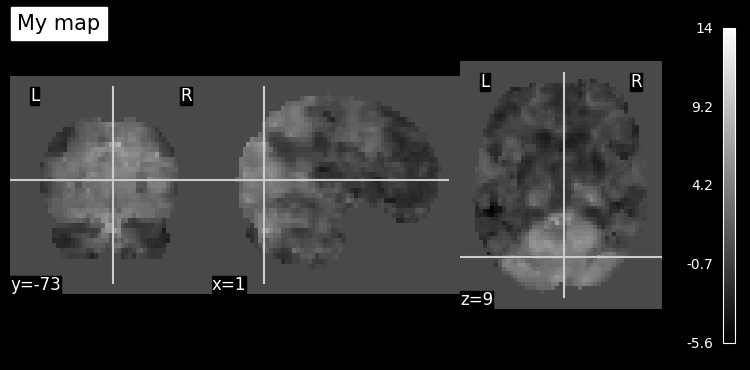

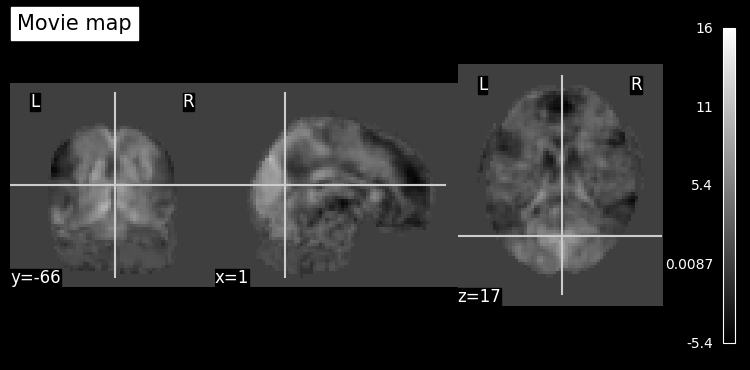

In [10]:
from nilearn import plotting, image

my_map = "/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/task-sleep_contrast-mreyemove_W-clean-with-fd-clamped-original-sleep/second_level_flame/flameo/stats/tstat1.nii.gz"
movie_map = "/Users/zach/Downloads/Sherlock data/npspmT_unthresholded_movie.nii"

# Quick visual check - overlay edges of one on the other
plotting.plot_anat(my_map, title="My map")
plotting.plot_anat(movie_map, title="Movie map")

In [11]:


# Check headers
import nibabel as nib
mine = nib.load(my_map)
movie = nib.load(movie_map)
print("Mine:", mine.shape, mine.affine)
print("Movie:", movie.shape, movie.affine)



Mine: (53, 65, 43) [[   3.    0.    0.  -78.]
 [   0.    3.    0. -114.]
 [   0.    0.    4.  -78.]
 [   0.    0.    0.    1.]]
Movie: (65, 77, 65) [[   3.     0.     0.   -96.5]
 [   0.     3.     0.  -132.5]
 [   0.     0.     3.   -78.5]
 [   0.     0.     0.     1. ]]


In [25]:
from nilearn import datasets, plotting

mni = datasets.load_mni152_template(resolution=2)
my_map =  nib.load("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/sub-16/func/glm_brain/sub-16_run_3_task-sleep_desc-mreyemove-glm-contrast-mreyemove_W-cope-clean-with-fd-clamped-original-sleep.nii.gz")

In [26]:
import numpy as np
cope_subj = nib.load("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/sub-16/func/glm_brain/sub-16_run_3_task-sleep_desc-mreyemove-glm-contrast-mreyemove_W-cope-clean-with-fd-clamped-original-sleep.nii.gz")
flame_out = nib.load("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/task-sleep_contrast-mreyemove_W-clean-with-fd-clamped-original-sleep/second_level_flame/flameo/stats/tstat1.nii.gz")
print("Subject COPE affine:\n", cope_subj.affine)
print("FLAME output affine:\n", flame_out.affine)
print("Match:", np.allclose(cope_subj.affine, flame_out.affine))

Subject COPE affine:
 [[   3.    0.    0.  -78.]
 [   0.    3.    0. -114.]
 [   0.    0.    4.  -78.]
 [   0.    0.    0.    1.]]
FLAME output affine:
 [[   3.    0.    0.  -78.]
 [   0.    3.    0. -114.]
 [   0.    0.    4.  -78.]
 [   0.    0.    0.    1.]]
Match: True


/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_8307/556038796.py:2: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(movie_map, bg_img=mni, title="Movie", cut_coords=(0, -31, 15))


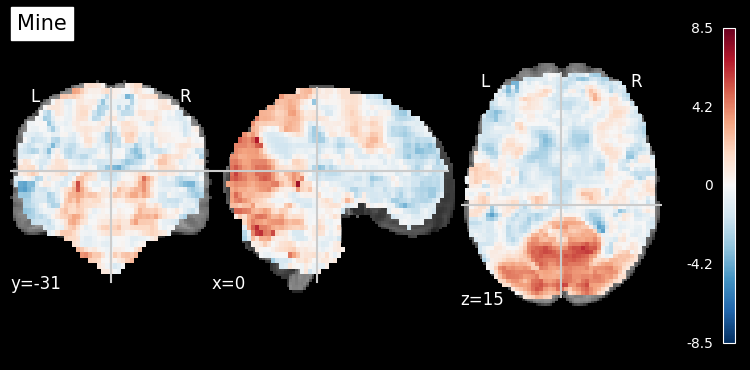

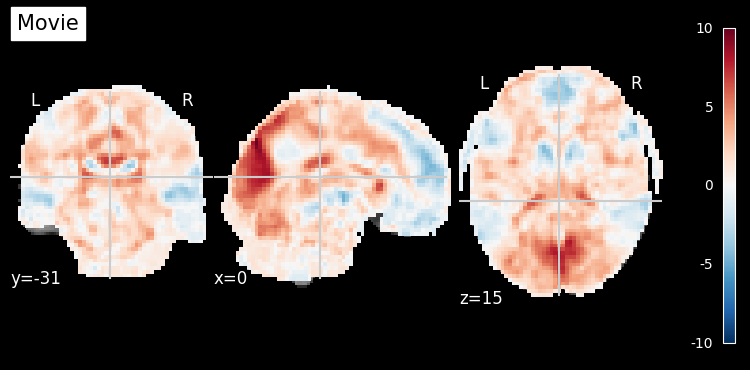

In [28]:

plotting.plot_stat_map(flame_out, bg_img=mni, title="Mine", cut_coords=(0, -31, 15))
plotting.plot_stat_map(movie_map, bg_img=mni, title="Movie", cut_coords=(0, -31, 15))


/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_8307/477750825.py:7: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  movie_resliced = image.resample_to_img(movie_map, my_map, interpolation="continuous")
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_8307/477750825.py:7: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  movie_resliced = image.resample_to_img(movie_map, my_map, interpolation="continuous")
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_8307/477750825.py:7: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  movie_resliced = image.resam

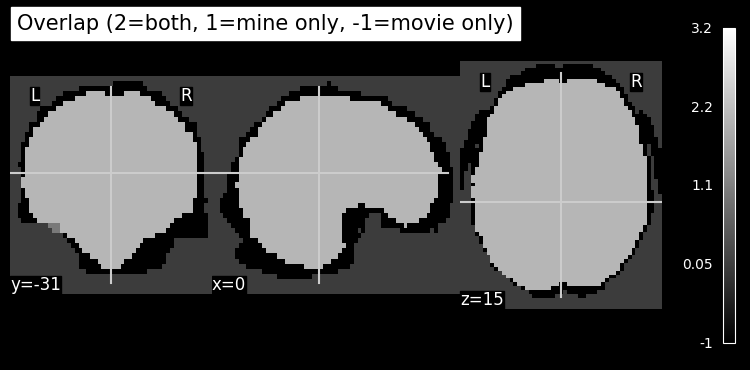

In [21]:


from nilearn import image, plotting
import numpy as np
import nibabel as nib

my_map = nib.load(my_map)
# Reslice movie to your grid
movie_resliced = image.resample_to_img(movie_map, my_map, interpolation="continuous")

# Create binary masks of where each map has data
my_data = np.abs(my_map.get_fdata()) > 0
movie_data = np.abs(movie_resliced.get_fdata()) > 0

# Overlap: 2 = both, 1 = only mine, -1 = only movie
overlap = np.zeros_like(my_data, dtype=float)
overlap[my_data & movie_data] = 2
overlap[my_data & ~movie_data] = 1
overlap[~my_data & movie_data] = -1

overlap_img = nib.Nifti1Image(overlap, my_map.affine)
plotting.plot_anat(overlap_img, cut_coords=(0, -31, 15), title="Overlap (2=both, 1=mine only, -1=movie only)")



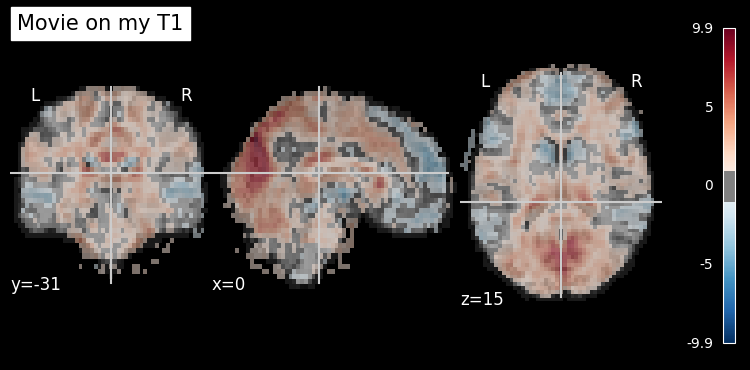

In [45]:
from mreyemove.plotting.glm import custom_cmap

# Your subject's anatomical in MNI space
anat = nib.load("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/fmriprep/sub-03/anat/sub-03_space-MNI152NLin2009cAsym_desc-preproc_T1w.nii.gz")
anat_resliced = image.resample_to_img(anat, movie_resliced, copy_header=True, force_resample=True)

movie_data = movie_resliced.get_fdata()
movie_data[np.isnan(movie_data)] = 0
movie_clean = image.new_img_like(movie_resliced, movie_data, copy_header=True)

# Plot edges of your anatomy with movie stat map
plotting.plot_stat_map(movie_clean, transparency=0.5, threshold=1, bg_img=anat_resliced, cut_coords=(0, -31, 15), title="Movie on my T1")